In [250]:
from scipy import constants as c

In [251]:
alpha = 1.1e-5
dT = 311 - 278
L = 1
alpha * dT * L

0.000363

In [252]:
import numpy as np

masses = (
    np.array(
        [
            32,
            28,
            39.9,
        ]
    )
    * 1e-3
)

abund = np.array(
    [
        0.21,
        0.78,
        0.01,
    ]
)

m = (masses.T @ abund) / c.Avogadro
m

np.float64(4.808755084628743e-26)

In [253]:
V = 30
A = 0.1
k = c.Boltzmann
T = 300

In [254]:
# for tau
(2 * V / (A)) * np.sqrt(m / (k * T))

np.float64(2.0443973575650025)

In [255]:
np.sqrt(m / (k * T)) ** -1

np.float64(293.48502030673495)

In [256]:
# for A
tau = 3600
(2 * V / tau) * np.sqrt(m / (k * T))

np.float64(5.678881548791673e-05)

In [257]:
c.g

9.80665

In [258]:
def pressure(z):
    P_0 = 1  # atm
    T = 280  # K
    return P_0 * np.exp(-(m * c.g / (c.k * T)) * z)

In [259]:
heights = np.array(
    [
        1430,
        3090,
        4420,
        8850,
    ]
)

pressure(heights)

array([0.83992658, 0.68595826, 0.58322593, 0.3397378 ])

In [260]:
Re = 6.4e6
h = 250e3
v = 8500
g = c.g

f1 = (2 * (Re + h) ** 2 * v**2) / (g**2 * Re**4)
t1 = -c.g * Re**2 / (Re + h)
t2 = 0.5 * v**2
f2 = t1 + t2
(f1 * f2 + 1) ** 0.5

0.1961313500437194

In [261]:
(((1 + 0.196) / (1 - 0.196)) * (6.4e6 + 250e3)) - Re

3492288.5572139286

In [262]:
c.G

6.6743e-11

In [263]:
from scipy import constants as const

m = 4.0  # kg # TODO: placeholder
v0 = 45e3  # m/s
r0 = 1e11  # m
alpha = (50 / 180) * np.pi
Ms = 2e30  # kg
G = const.G  # N \cdot m^2 / s^2

T = 0.5 * m * v0**2
U = -G * (Ms * m) / r0
l = r0 * v0 * m * np.sin(alpha)
num = 2 * (T + U) * l**2
denom = ((G * Ms * m) ** 2) * m
epsilon = np.sqrt((num / denom) + 1)
c = (l**2) / (G * Ms * m**2)
delta = np.acos((c - r0) / (epsilon * r0))

print(epsilon, c, delta)

0.7550069108471575 89021978326.3988 1.716716544886858


In [264]:
au_to_m = 1.495979e11  # 1 au in m
y_to_s = 3.15576e7  # 1 year in s
G = const.G
Ms = 2e30  # kg
a = 15.5 * au_to_m  # m
t = 0.5 * (4 * (a**3) * np.pi**2 / (G * Ms)) ** 0.5  # s
t / (y_to_s)

30.42382671941122

In [265]:
from scipy.optimize import fsolve, minimize_scalar
import numpy as np

G = const.G
l = 1
m = 1
mu = 1  # Approximately
k = 1
E = -0.1


def Ueff(r):
    return -(2 / 3) * k * (1 / r**1.5) + (l**2 / (2 * mu * r**2))


out = minimize_scalar(Ueff, bounds=(0.001, 10))
r0 = out.x
Ueffmin = out.fun
r0

np.float64(0.9999998693614462)

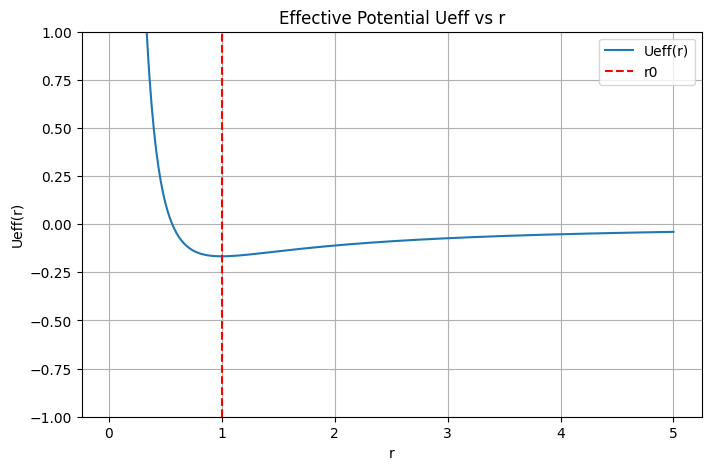

In [266]:
import matplotlib.pyplot as plt

# User can set y-bounds here
ymin = -1  # e.g., -1
ymax = 1  # e.g., 1

r_vals = np.linspace(0.01, 5 * r0, 500)
Ueff_vals = [Ueff(r) for r in r_vals]

plt.figure(figsize=(8, 5))
plt.plot(r_vals, Ueff_vals, label="Ueff(r)")
plt.axvline(r0, color="red", linestyle="--", label="r0")
plt.xlabel("r")
plt.ylabel("Ueff(r)")
plt.title("Effective Potential Ueff vs r")
plt.legend()
plt.grid(True)
if ymin is not None or ymax is not None:
    plt.ylim(ymin, ymax)
plt.show()


In [267]:
def f(r):
    return Ueff(r) - E


rmin = fsolve(f, 0.1)[0]
rmin

np.float64(0.6670792799882106)

In [268]:
from scipy.integrate import solve_ivp
import numpy as np


def transformed_system(t, state):
    u, du = state
    coeff = 1  # Choose units s.t. m = k = l = 1
    # (Note: \mu = 1 / 2)
    ddu = -u + coeff * np.sqrt(u)
    return [du, ddu]


revs = 100
phispan = (0.001, revs * 2 * np.pi)
state0 = [1 / rmin, 0.0]
phieval = np.linspace(
    phispan[0],
    phispan[1],
    10000,
)
out = solve_ivp(
    transformed_system,
    phispan,
    state0,
    t_eval=phieval,
)


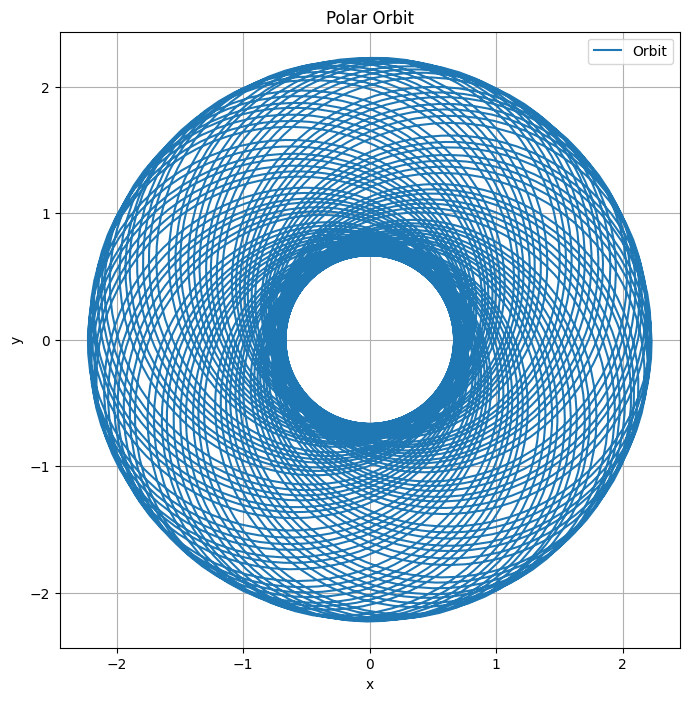

In [269]:
import matplotlib.pyplot as plt

# The solution of transformed_system gives u = 1/r vs phi
u_vals = out.y[0]  # u = 1/r
phi_vals = out.t
r_vals = 1 / u_vals

# Convert (r, phi) to (x, y) for 2D plotting
x_vals = r_vals * np.cos(phi_vals)
y_vals = r_vals * np.sin(phi_vals)

plt.figure(figsize=(8, 8))
plt.plot(x_vals, y_vals, label="Orbit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polar Orbit")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


In [271]:
import sympy as sp
from sympy import latex, simplify, integrate, symbols, sqrt

# Define symbolic variables
u, alpha, beta = sp.symbols("u alpha beta", real=True)

# Define the integrand
integrand = 1 / sp.sqrt(-(u**2) + alpha * u + beta)

# Compute the indefinite integral symbolically
integral = integrate(integrand, u)

# Simplify the result
integral_simplified = simplify(integral)

# Display as LaTeX in Jupyter notebook
from IPython.display import display, Math

display(Math(r"\text{Indefinite integral:}"))
display(Math(latex(integral_simplified)))

# For definite integral (example limits)
a, b = symbols("a b", real=True)
definite_integral = integrate(integrand, (u, a, b))
display(Math(r"\text{Definite integral (symbolic limits):}"))
display(Math(latex(simplify(definite_integral))))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>